# NB_04 · Évaluation et comparaison des modèles
### Prédiction d'annulation de réservations d'hôtel

**Objectif :** évaluer les 3 modèles entraînés dans `NB_03_Dev_Modele` avec plusieurs métriques
(Accuracy, Precision, Recall, F1-score, matrice de confusion) et choisir le meilleur modèle.

**Métrique importante :** le *Recall* de la classe 1 (annulations) est particulièrement suivi,
car c'est la classe que l'hôtel souhaite détecter pour agir en amont.


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

X_test = pd.read_csv('../Donnees/processed/X_test.csv')
y_test = pd.read_csv('../Donnees/processed/y_test.csv').squeeze()

log_reg = joblib.load('../Modeles/logistic_regression.pkl')
tree_clf = joblib.load('../Modeles/decision_tree.pkl')
rf_clf = joblib.load('../Modeles/random_forest.pkl')

models = {
    'Logistic Regression': log_reg,
    'Decision Tree': tree_clf,
    'Random Forest': rf_clf
}
print("Modèles chargés :", list(models.keys()))


Modèles chargés : ['Logistic Regression', 'Decision Tree', 'Random Forest']


## 1. Calcul des métriques pour chaque modèle

In [2]:
results = []
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (classe 1)': precision_score(y_test, y_pred),
        'Recall (classe 1)': recall_score(y_test, y_pred),
        'F1-score (classe 1)': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).set_index('Modèle').round(4)
results_df


,Accuracy,Precision (classe 1),Recall (classe 1),F1-score (classe 1)
Modèle,,,,
Logistic Regression,0.7918,0.6753,0.4580,0.5458
Decision Tree,0.8209,0.6858,0.6353,0.6596
Random Forest,0.8519,0.7868,0.6279,0.6984


## 2. Matrices de confusion

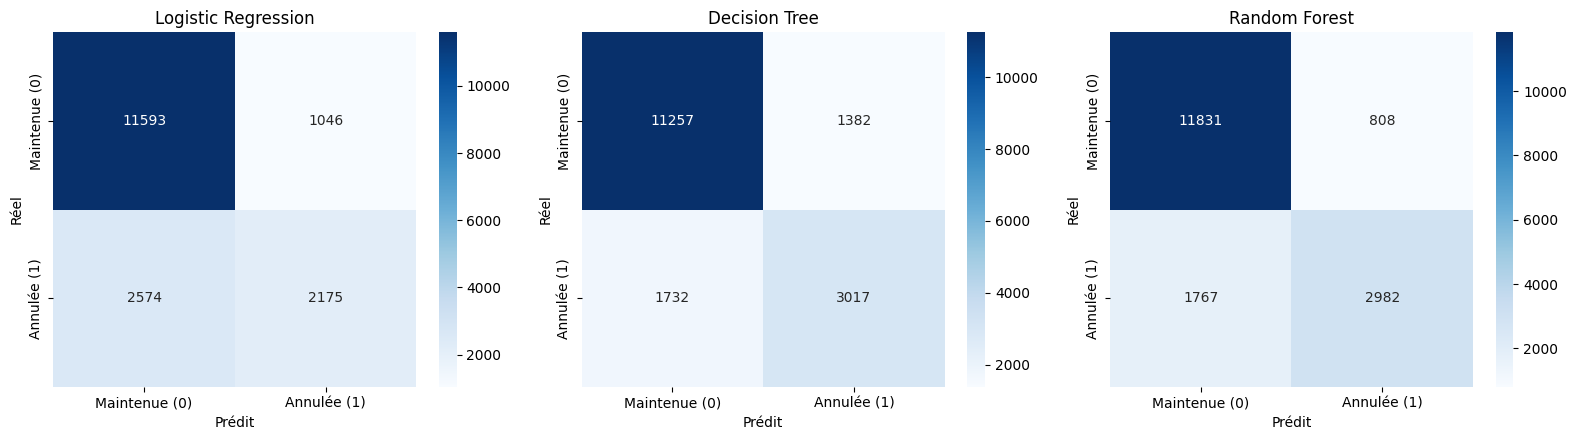

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Maintenue (0)','Annulée (1)'],
                yticklabels=['Maintenue (0)','Annulée (1)'])
    ax.set_title(name)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
plt.tight_layout()
plt.show()


## 3. Rapport détaillé par modèle

In [4]:
for name, y_pred in predictions.items():
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['Maintenue (0)', 'Annulée (1)']))
    print()


--- Logistic Regression ---
               precision    recall  f1-score   support

Maintenue (0)       0.82      0.92      0.86     12639
  Annulée (1)       0.68      0.46      0.55      4749

     accuracy                           0.79     17388
    macro avg       0.75      0.69      0.71     17388
 weighted avg       0.78      0.79      0.78     17388


--- Decision Tree ---
               precision    recall  f1-score   support

Maintenue (0)       0.87      0.89      0.88     12639
  Annulée (1)       0.69      0.64      0.66      4749

     accuracy                           0.82     17388
    macro avg       0.78      0.76      0.77     17388
 weighted avg       0.82      0.82      0.82     17388


--- Random Forest ---
               precision    recall  f1-score   support

Maintenue (0)       0.87      0.94      0.90     12639
  Annulée (1)       0.79      0.63      0.70      4749

     accuracy                           0.85     17388
    macro avg       0.83      0.78    

## 4. Comparaison visuelle des modèles

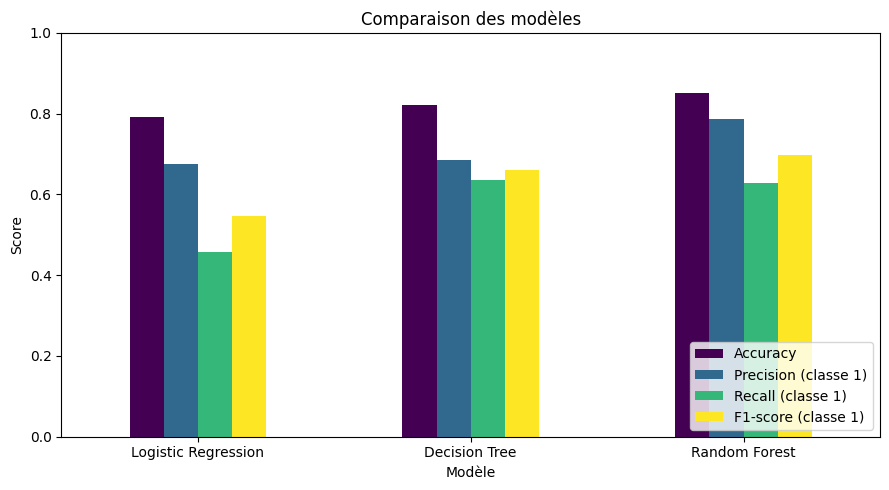

In [5]:
results_df[['Accuracy','Precision (classe 1)','Recall (classe 1)','F1-score (classe 1)']].plot(
    kind='bar', figsize=(9,5), colormap='viridis'
)
plt.title("Comparaison des modèles")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 5. Choix du meilleur modèle

**Pourquoi pas seulement l'Accuracy ?** La classe 1 correspond aux annulations, l'objectif métier
principal. Il faut donc regarder aussi Precision, Recall et F1-score pour choisir un modèle réellement
utile en contexte réel (détecter les réservations à risque, pas seulement bien classer l'ensemble).


In [6]:
best_model_name = results_df['F1-score (classe 1)'].idxmax()
print(f"Modèle retenu (meilleur F1-score classe 1) : {best_model_name}")
results_df.loc[[best_model_name]]


Modèle retenu (meilleur F1-score classe 1) : Random Forest


,Accuracy,Precision (classe 1),Recall (classe 1),F1-score (classe 1)
Modèle,,,,
Random Forest,0.8519,0.7868,0.6279,0.6984


## 6. Conclusion

Le modèle retenu offre le meilleur compromis entre performance globale (Accuracy) et capacité à
détecter les réservations à risque d'annulation (Recall / F1-score classe 1). Il peut être utilisé
par l'hôtel pour identifier les réservations à risque et déclencher des actions préventives (rappel,
confirmation, politique de dépôt, offre ciblée) avant la date d'arrivée.

**Perspectives d'amélioration :**
- Validation croisée (K-fold) pour une estimation plus robuste
- Optimisation des hyperparamètres (GridSearchCV / RandomizedSearchCV)
- Feature engineering (`total_guests`, `total_nights`, regroupement des pays rares...)
- Ajustement du seuil de décision selon le coût métier des faux négatifs/positifs
- Analyse de l'importance des variables (feature importance) pour expliquer les facteurs d'annulation
